# Churn Prediction — E-Commerce Shop

Supervised binary classification: will a customer stop ordering in the next 90 days?

- **Dataset:** `data/synthetic_users.csv` (3000 users, generated by `generate_dataset.py`)
- **Features:** account age, orders count, total spent, average order value, days since last order, favorites count
- **Target:** `churned` (1 = expected to leave)
- **Served by:** `GET /analytics/churn/{user_id}`

## <center> <span style="color:blue"> Data loading and inspection 

In [108]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

RANDOM_SEED = 42

BASE_DIR = Path.cwd()
if BASE_DIR.name != "ml":
    BASE_DIR = BASE_DIR / "ml"

DATASET_PATH = BASE_DIR / "data" / "synthetic_users.csv"
MODEL_PATH = BASE_DIR / "model" / "churn_model.joblib"

FEATURE_COLUMNS = [
    "account_age_days",
    "orders_count",
    "total_spent",
    "avg_order_value",
    "days_since_last_order",
    "favorites_count",
]
TARGET_COLUMN = "churned"

In [109]:
dataset = pd.read_csv(DATASET_PATH)
print(dataset.shape)
dataset.head(10)

(3000, 7)


,account_age_days,orders_count,total_spent,avg_order_value,days_since_last_order,favorites_count,churned
0,98,7,430.78,61.54,7,4,0
1,847,3,253.59,84.53,89,7,0
2,717,4,289.48,72.37,141,6,1
3,481,3,103.62,34.54,152,1,1
4,474,5,145.70,29.14,79,2,1
5,940,3,385.14,128.38,14,4,0
6,95,3,171.84,57.28,95,2,0
7,763,7,825.37,117.91,134,4,0
8,221,3,138.39,46.13,82,2,0
9,104,3,407.55,135.85,104,2,1


In [110]:
dataset.info()
dataset.describe()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   account_age_days       3000 non-null   int64  
 1   orders_count           3000 non-null   int64  
 2   total_spent            3000 non-null   float64
 3   avg_order_value        3000 non-null   float64
 4   days_since_last_order  3000 non-null   int64  
 5   favorites_count        3000 non-null   int64  
 6   churned                3000 non-null   int64  
dtypes: float64(2), int64(5)
memory usage: 164.3 KB


,account_age_days,orders_count,total_spent,avg_order_value,days_since_last_order,favorites_count,churned
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,548.721333,3.990000,297.932453,75.052100,92.677667,3.019000,0.463333
std,316.862596,2.029271,247.368482,44.412291,85.971473,1.757556,0.498737
min,1.000000,0.000000,0.000000,2.580000,1.000000,0.000000,0.000000
25%,272.000000,3.000000,126.082500,42.405000,42.000000,2.000000,0.000000
50%,545.000000,4.000000,229.015000,65.785000,84.000000,3.000000,0.000000
75%,826.000000,5.000000,398.117500,98.452500,130.000000,4.000000,1.000000
max,1094.000000,14.000000,2055.040000,362.940000,1084.000000,11.000000,1.000000


In [111]:
print(f"Duplicated rows: {dataset.duplicated().sum()}")

Duplicated rows: 0


## <center> <span style="color:blue"> Data analysis

churned
0    1610
1    1390
Name: count, dtype: int64
churned
0    0.536667
1    0.463333
Name: proportion, dtype: float64


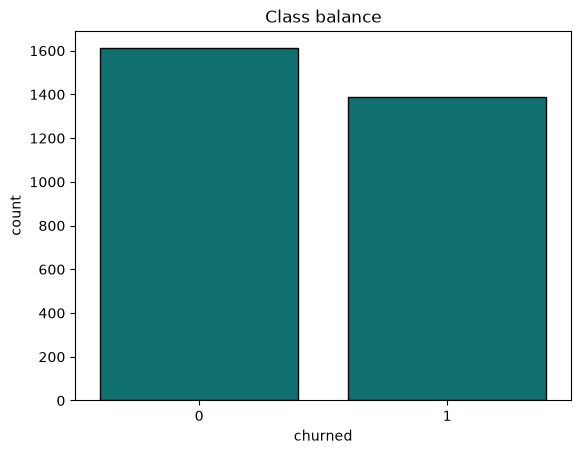

In [112]:
print(dataset[TARGET_COLUMN].value_counts())
print(dataset[TARGET_COLUMN].value_counts(normalize=True))

sns.countplot(data=dataset, x=TARGET_COLUMN, color='Teal', edgecolor="black")
plt.title("Class balance")
plt.show()

In [113]:
dataset.corr()

,account_age_days,orders_count,total_spent,avg_order_value,days_since_last_order,favorites_count,churned
account_age_days,1.000000,0.023789,0.001469,-0.022087,0.135853,-0.010957,0.141465
orders_count,0.023789,1.000000,0.603972,-0.016931,-0.184954,0.014264,-0.292929
total_spent,0.001469,0.603972,1.000000,0.701058,-0.127058,0.022880,-0.324923
avg_order_value,-0.022087,-0.016931,0.701058,1.000000,-0.003531,0.004195,-0.163016
days_since_last_order,0.135853,-0.184954,-0.127058,-0.003531,1.000000,-0.006781,0.406825
favorites_count,-0.010957,0.014264,0.022880,0.004195,-0.006781,1.000000,-0.052651
churned,0.141465,-0.292929,-0.324923,-0.163016,0.406825,-0.052651,1.000000


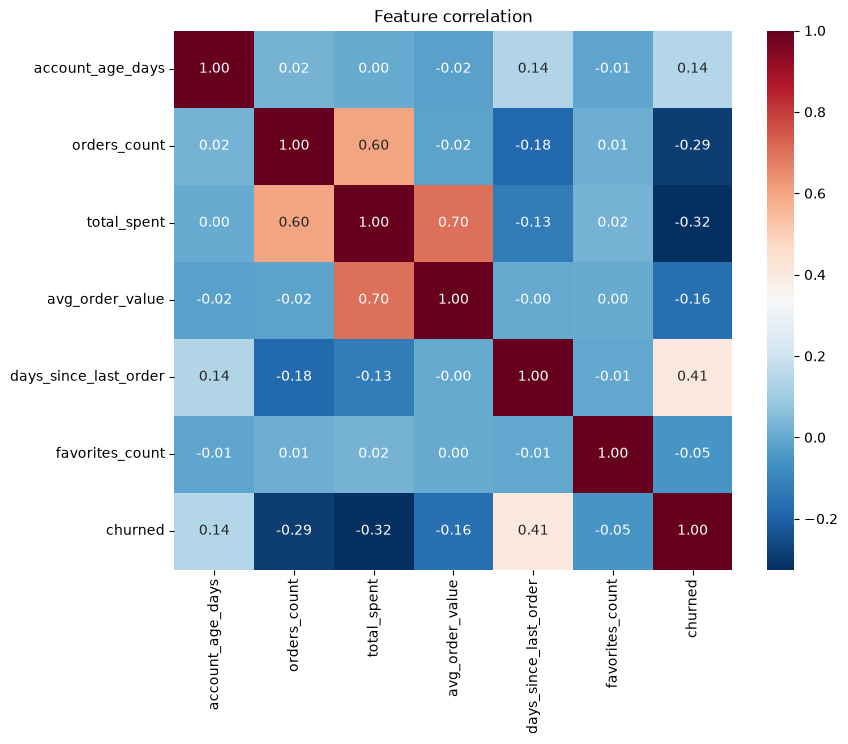

In [114]:
plt.figure(figsize=(9, 7))
sns.heatmap(dataset.corr(numeric_only=True), annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Feature correlation")
plt.show()

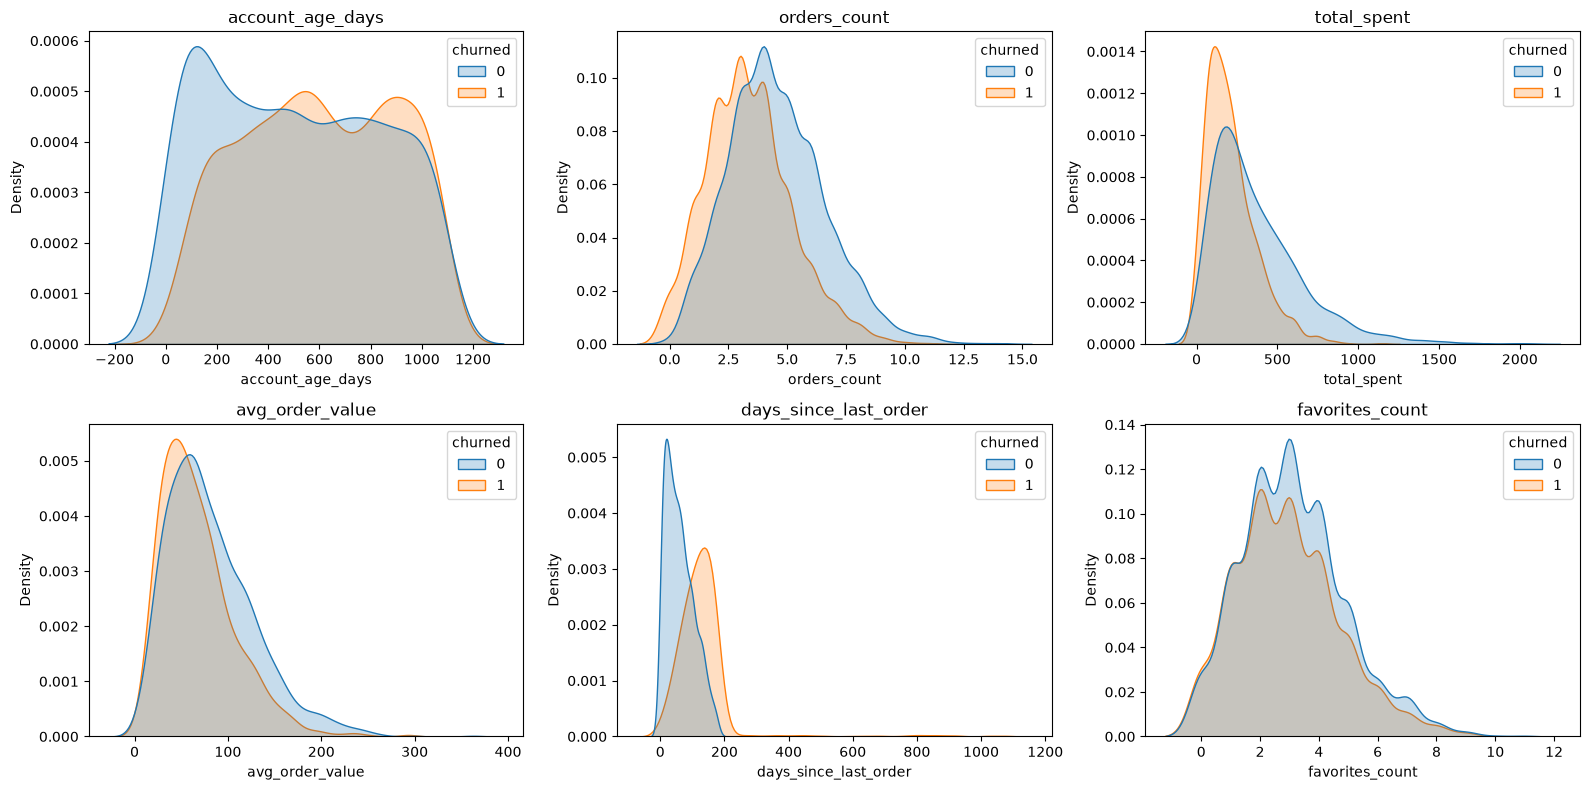

In [115]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for axis, column in zip(axes.flatten(), FEATURE_COLUMNS):
    sns.kdeplot(data=dataset, x=column, hue=TARGET_COLUMN, fill=True, ax=axis)
    axis.set_title(column)
plt.tight_layout()
plt.show()

## <center> <span style="color:blue"> Train / test split

In [116]:
features = dataset[FEATURE_COLUMNS]
target = dataset[TARGET_COLUMN]

features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size=0.2, random_state=RANDOM_SEED, stratify=target
)
print(features_train.shape, features_test.shape)

(2400, 6) (600, 6)


## <center>  <span style="color:blue"> Model training and comparison

In [117]:
baseline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(random_state=RANDOM_SEED, max_iter=1000)),
    ]
)
baseline.fit(features_train, target_train)
baseline_auc = roc_auc_score(target_test, baseline.predict_proba(features_test)[:, 1])
print(f"Baseline (LogisticRegression) ROC-AUC: {baseline_auc:.4f}")

Baseline (LogisticRegression) ROC-AUC: 0.8822


In [118]:
pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler()),
        ("classifier", RandomForestClassifier(random_state=RANDOM_SEED)),
    ]
)

param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [4, 8, 10],
    "classifier__min_samples_leaf": [1, 5, 10],
}

search = GridSearchCV(
    estimator=pipeline, param_grid=param_grid, cv=5, scoring="roc_auc", n_jobs=-1
)
search.fit(features_train, target_train)

print(f"Best params: {search.best_params_}")
print(f"Best CV ROC-AUC: {search.best_score_:.4f}")

Best params: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 100}
Best CV ROC-AUC: 0.8650


## <center> <span style="color:blue"> Evaluation of the selected model

In [119]:
baseline_cv = cross_val_score(
    baseline, features_train, target_train, cv=5, scoring="roc_auc"
)
rf_test_auc = roc_auc_score(target_test, search.predict_proba(features_test)[:, 1])

print(f"LogisticRegression  CV ROC-AUC: {baseline_cv.mean():.4f} (+/- {baseline_cv.std():.4f})")
print(f"RandomForest        CV ROC-AUC: {search.best_score_:.4f}")
print()
print(f"LogisticRegression  Test ROC-AUC: {baseline_auc:.4f}")
print(f"RandomForest        Test ROC-AUC: {rf_test_auc:.4f}")

LogisticRegression  CV ROC-AUC: 0.8726 (+/- 0.0066)
RandomForest        CV ROC-AUC: 0.8650

LogisticRegression  Test ROC-AUC: 0.8822
RandomForest        Test ROC-AUC: 0.8773


              precision    recall  f1-score   support

           0       0.79      0.83      0.81       322
           1       0.79      0.75      0.77       278

    accuracy                           0.79       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.79      0.79      0.79       600

Test ROC-AUC: 0.8822


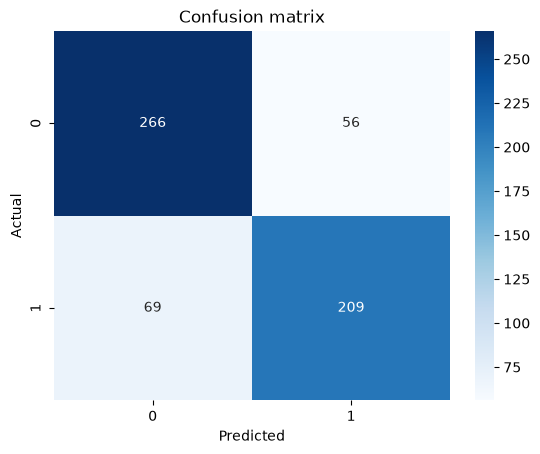

In [120]:
predictions = baseline.predict(features_test)
probabilities = baseline.predict_proba(features_test)[:, 1]

print(classification_report(target_test, predictions))
print(f"Test ROC-AUC: {roc_auc_score(target_test, probabilities):.4f}")

sns.heatmap(
    confusion_matrix(target_test, predictions), annot=True, fmt="d", cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix")
plt.show()

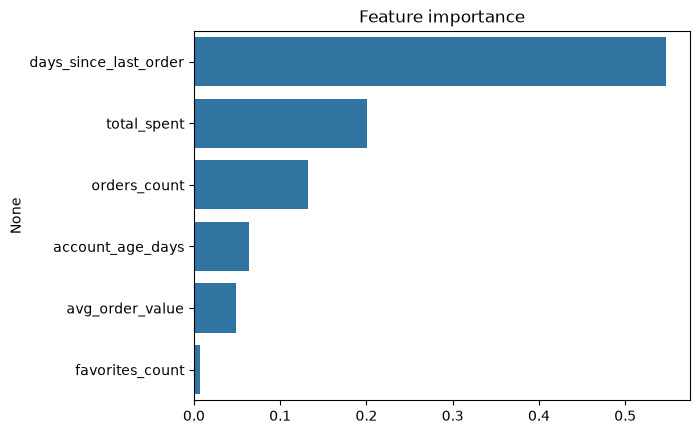

days_since_last_order    0.547619
total_spent              0.200909
orders_count             0.132046
account_age_days         0.064079
avg_order_value          0.048516
favorites_count          0.006830
dtype: float64

In [121]:
importances = pd.Series(
    search.best_estimator_.named_steps["classifier"].feature_importances_,
    index=FEATURE_COLUMNS,
).sort_values(ascending=False)

sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature importance")
plt.show()

importances

In [122]:
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(
    {"pipeline": baseline, "feature_columns": FEATURE_COLUMNS},
    MODEL_PATH,
)
print(f"Saved model to {MODEL_PATH}")

Saved model to d:\projects\E_Commerce_Web\ml\model\churn_model.joblib


## Conclusions

**Model selection.** Logistic regression outperformed the tuned Random Forest on both
comparable metrics - CV ROC-AUC 0.8726 vs 0.8650, test ROC-AUC 0.8822 vs 0.8773.
Since the ensemble gave no improvement, the simpler and more interpretable model was
selected for production.

**Why the ensemble did not help.** GridSearch selected the most regularised forest in
the grid (`max_depth=4`, `min_samples_leaf=5`), which indicates a smooth and simple
decision boundary - deeper trees only fit noise.

**Feature insights.** Days since last order dominates, explaining over half of the
predictive signal, followed by total spent and orders count. This matches classic
RFM behaviour in retail. Favorites count turned out to be almost useless (0.7%),
so wishlist activity is a poor churn indicator in this data.

**Limitation.** The dataset is synthetic, generated from a logistic model with noise.
Real purchase history would likely yield lower scores and possibly different feature
rankings - these metrics should be read as a demonstration of the pipeline, not as a
production benchmark.